In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from src.getdata_utils import load_data, split_data

In [3]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


Numeric features: ['age', 'day', 'campaign', 'previous', 'was_prev_contacted', 'balance_slog']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
scale_pos_weight ≈ 7.55 (neg/pos)
Base learners included: ['xgb', 'rf']
Meta LR VAL AUC:  0.806
Meta XGB VAL AUC: 0.808

Stacked Ensemble (XGB meta) — Test ROC-AUC: 0.808
Base XGB — Test ROC-AUC: 0.806
Base RF — Test ROC-AUC: 0.794

Best Val F1 threshold: 0.285 | F1=0.496, Precision=0.455, Recall=0.545

VALIDATION @ threshold=0.285
Confusion matrix:
 [[5836  552]
 [ 385  461]]
Precision: 0.455  Recall: 0.545  F1: 0.496  ROC-AUC: 0.808

TEST @ threshold=0.285
Confusion matrix:
 [[7354  631]
 [ 523  535]]
Precision: 0.459  Recall: 0.506  F1: 0.481  ROC-AUC: 0.808

Permutation importance (ensemble meta-features) — Validation:
     feature  importance_mean  importance_std
0  proba_XGB         0.017183        0.001040
1 

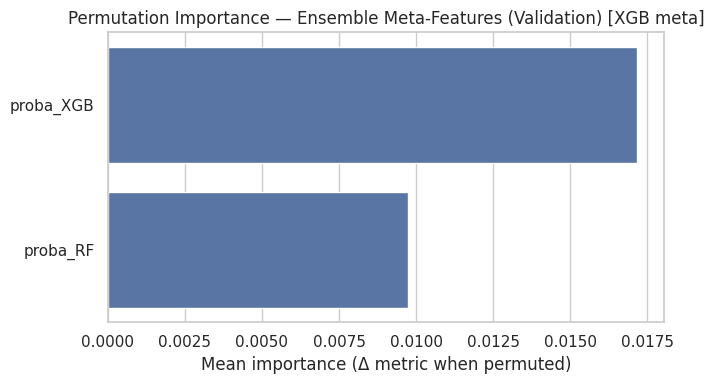


SHAP — Ensemble meta-learner (Validation meta-features)


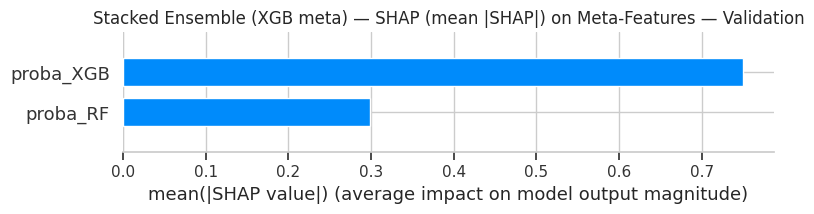

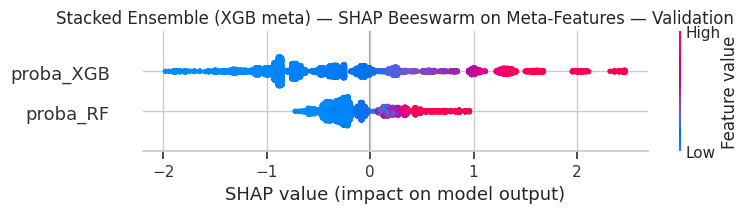


Permutation importance — Tuned XGB pipeline (original features) — Validation:
               feature  importance_mean  importance_std
9                month         0.134739        0.003363
8                  day         0.065579        0.002128
7              contact         0.053912        0.001423
12            poutcome         0.027468        0.000868
5              housing         0.016132        0.001879
11            previous         0.011805        0.001135
0                  age         0.009359        0.001385
10            campaign         0.004424        0.001484
13  was_prev_contacted         0.002502        0.000477
6                 loan         0.000194        0.001160
4              default         0.000041        0.000303
1                  job        -0.000954        0.000888
14        balance_slog        -0.002032        0.001703
3            education        -0.002350        0.001114
2              marital        -0.003732        0.001058


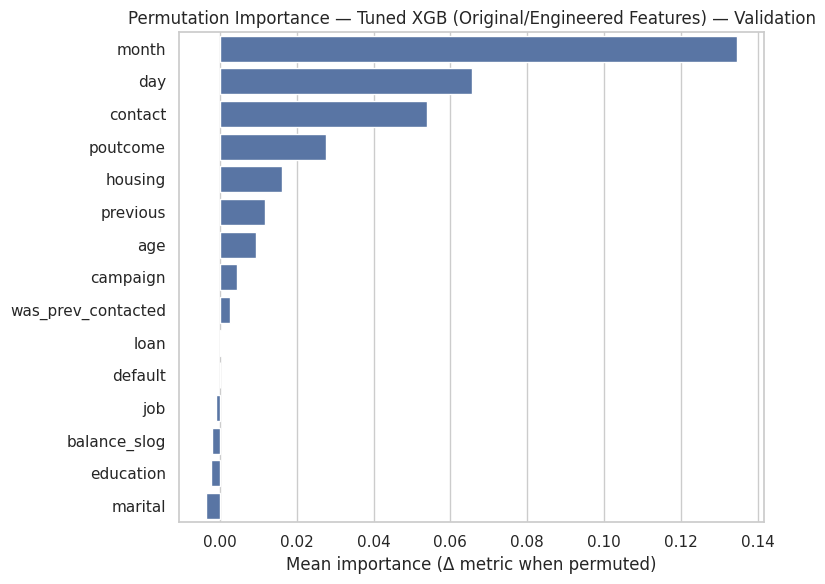


SHAP — Tuned XGB base model (Validation features)


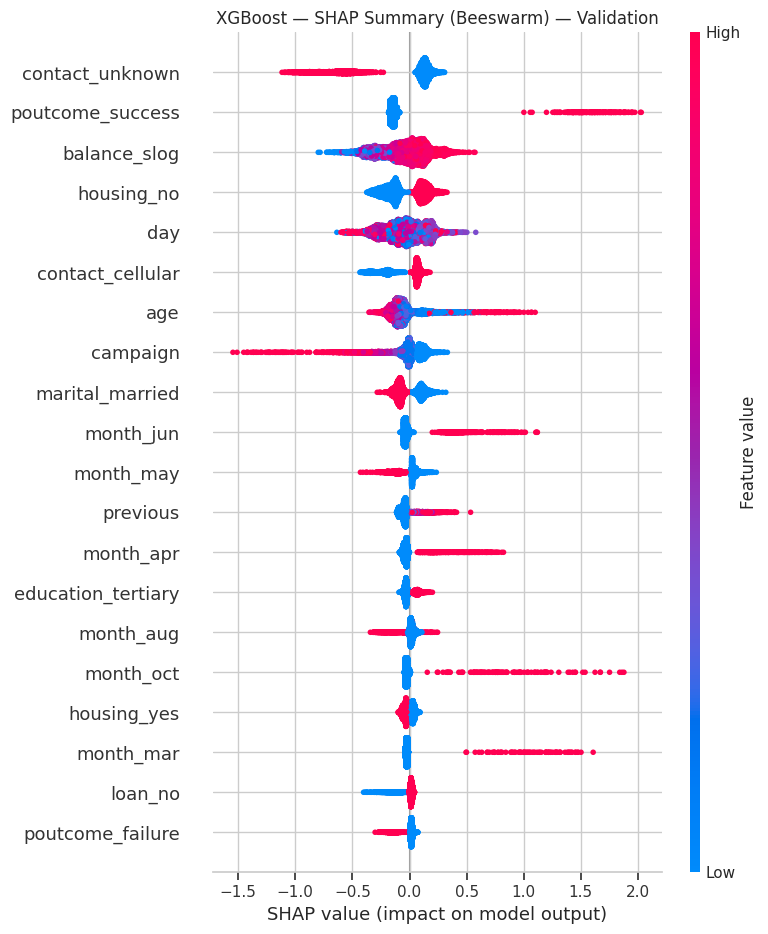

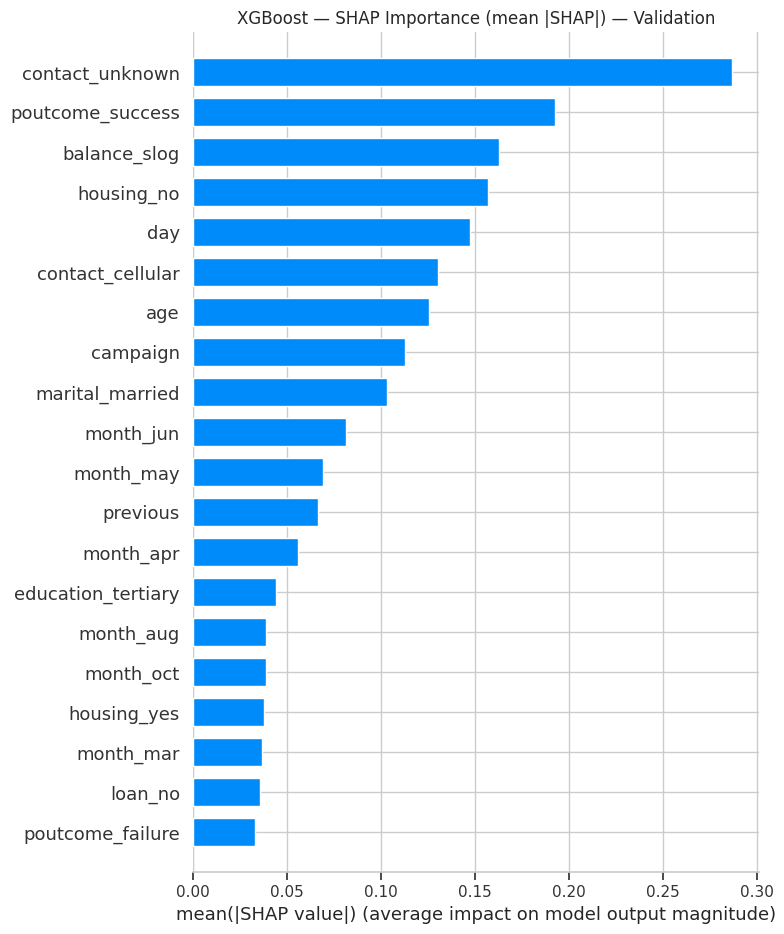


XGBoost — SHAP Importance Aggregated by Original Feature (Validation):
          feature_orig  mean_abs_shap
11               month       0.455573
3              contact       0.422335
12            poutcome       0.237281
7              housing       0.194962
1         balance_slog       0.162593
4                  day       0.147368
10             marital       0.141393
0                  age       0.125496
2             campaign       0.112891
6            education       0.069950
13            previous       0.066292
8                  job       0.059463
9                 loan       0.050932
14  was_prev_contacted       0.010289
5              default       0.000959


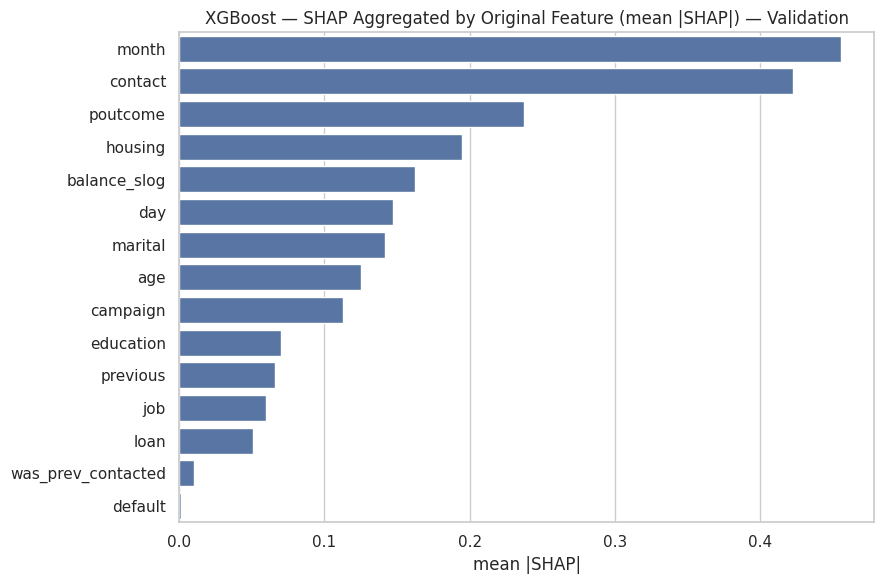

   age           job   marital  education default housing loan   contact  day  \
0   40   blue-collar   married    primary      no     yes  yes   unknown    8   
1   44    technician   married  secondary      no     yes   no   unknown   30   
2   31      services   married  secondary      no     yes   no   unknown   20   
3   36   blue-collar   married    primary      no     yes   no   unknown   23   
4   34      services    single  secondary      no     yes   no  cellular    4   
5   41    management    single  secondary      no      no   no  cellular   31   
6   43  entrepreneur   married   tertiary      no      no   no   unknown    3   
7   64       retired  divorced    primary      no      no   no  cellular   23   
8   35        admin.  divorced  secondary      no      no   no  cellular   28   
9   44      services  divorced   tertiary      no      no  yes  cellular   19   

  month  campaign  previous poutcome  was_prev_contacted  balance_slog  \
0   may         2         0  unkno

In [4]:
# ==========================================
# 0) Imports
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_recall_fscore_support,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import shap  # pip install shap ipywidgets
from scipy import sparse

sns.set_theme(style="whitegrid")
np.random.seed(42)

# ==========================================
# 1) Preprocessing and Feature Engineering
# ==========================================
df2 = df.copy()

# Remove duration (leakage w.r.t. "y")
if "duration" in df2.columns:
    df2 = df2.drop(columns=["duration"])

# Create was_prev_contacted from pdays; drop pdays
if "pdays" in df2.columns:
    df2["was_prev_contacted"] = (df2["pdays"] != -1).astype(int)
    df2 = df2.drop(columns=["pdays"])

# Signed log of balance; drop raw balance
if "balance" in df2.columns:
    df2["balance_slog"] = np.sign(df2["balance"]) * np.log1p(np.abs(df2["balance"]))
    df2 = df2.drop(columns=["balance"])

# Encode target
df2["y_binary"] = df2["y"].map({"no": 0, "yes": 1}).astype(int)

X = df2.drop(columns=["y", "y_binary"])
y = df2["y_binary"]

# Identify numeric vs categorical
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

# ==========================================
# 2) Train / Val / Test split
# ==========================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)
print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# class imbalance ratio for XGB
neg, pos = np.bincount(y_trainval)
scale_pos_weight = neg / pos
print(f"scale_pos_weight ≈ {scale_pos_weight:.2f} (neg/pos)")

# ==========================================
# 3) Preprocessor
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

# ==========================================
# 4) Tuned XGB params (from prior search)
# ==========================================
TUNED_XGB_PARAMS = dict(
    n_estimators=737,
    learning_rate=0.010455542546159682,
    max_depth=6,
    subsample=0.8345272428958741,
    colsample_bytree=0.7304414628598096,
    min_child_weight=6,
    gamma=1.3270035382161116,
    reg_lambda=1.4712275071724532,
)

# ==========================================
# 5) Base model builders (XGB + RF only)
# ==========================================
def make_xgb():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", XGBClassifier(
            **TUNED_XGB_PARAMS,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
            tree_method="hist",
            scale_pos_weight=scale_pos_weight
        )),
    ])

def make_rf():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=700,
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )),
    ])

base_builders = {"xgb": make_xgb, "rf": make_rf}
print("Base learners included:", list(base_builders.keys()))

# ==========================================
# 6) Stacking (OOF meta-features) with calibrated bases (isotonic)
#    + compare LR meta vs tiny XGB meta; keep the better by VAL AUC
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF meta for Train+Val
oof_meta = pd.DataFrame(index=y_trainval.index, columns=base_builders.keys(), dtype=float)
oof_meta[:] = np.nan

# Averaged base predictions on TEST
test_meta_parts = {name: np.zeros(len(X_test), dtype=float) for name in base_builders.keys()}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    X_tr, X_va = X_trainval.iloc[tr_idx], X_trainval.iloc[va_idx]
    y_tr, y_va = y_trainval.iloc[tr_idx], y_trainval.iloc[va_idx]

    for name, builder in base_builders.items():
        base_pipe = builder()
        calib = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
        calib.fit(X_tr, y_tr)

        oof_meta.loc[y_trainval.iloc[va_idx].index, name] = calib.predict_proba(X_va)[:, 1]
        test_meta_parts[name] += calib.predict_proba(X_test)[:, 1] / skf.n_splits

assert not oof_meta.isna().any().any(), "OOF meta-features contain NaNs."

meta_feature_names = [f"proba_{k.upper()}" for k in base_builders.keys()]
test_meta = np.column_stack([test_meta_parts[name] for name in base_builders.keys()])

# Build validation meta-features (fit bases on Train only)
val_meta_feats = []
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_train = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_train.fit(X_train, y_train)
    val_meta_feats.append(calib_train.predict_proba(X_val)[:, 1])
val_meta = np.column_stack(val_meta_feats)

# Option A: Logistic Regression meta
meta_lr = LogisticRegression(solver="lbfgs", max_iter=3000, C=1.0, n_jobs=-1, random_state=42)
meta_lr.fit(oof_meta.values, y_trainval.values)
val_auc_lr = roc_auc_score(y_val, meta_lr.predict_proba(val_meta)[:, 1])

# Option B: tiny XGB meta
meta_xgb = XGBClassifier(
    n_estimators=200, max_depth=2, learning_rate=0.05,
    subsample=0.9, colsample_bytree=1.0,
    eval_metric="logloss", random_state=42, n_jobs=-1, tree_method="hist"
)
meta_xgb.fit(oof_meta.values, y_trainval.values)
val_auc_xgb = roc_auc_score(y_val, meta_xgb.predict_proba(val_meta)[:, 1])

print(f"Meta LR VAL AUC:  {val_auc_lr:.3f}")
print(f"Meta XGB VAL AUC: {val_auc_xgb:.3f}")

use_meta = "xgb" if val_auc_xgb >= val_auc_lr else "lr"
meta_final = meta_xgb if use_meta == "xgb" else meta_lr

# Evaluate on TEST
test_meta_proba = meta_final.predict_proba(test_meta)[:, 1]
ensemble_auc = roc_auc_score(y_test, test_meta_proba)
print(f"\nStacked Ensemble ({use_meta.upper()} meta) — Test ROC-AUC: {ensemble_auc:.3f}")

# Base model TEST AUCs (calibrated on full Train+Val)
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_full = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_full.fit(X_trainval, y_trainval)
    proba = calib_full.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"Base {name.upper()} — Test ROC-AUC: {auc:.3f}")

# ==========================================
# 7) Threshold tuning on VALIDATION (maximize F1)
# ==========================================
prec, rec, thr = precision_recall_curve(y_val, meta_final.predict_proba(val_meta)[:, 1])
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
best_idx = np.nanargmax(f1s)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"\nBest Val F1 threshold: {best_thr:.3f} | F1={f1s[best_idx]:.3f}, "
      f"Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}")

def print_metrics(split, y_true, y_prob, thr):
    y_hat = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary")
    print(f"\n{split} @ threshold={thr:.3f}")
    print("Confusion matrix:\n", cm)
    print(f"Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}  ROC-AUC: {roc_auc_score(y_true, y_prob):.3f}")

# Print VAL/TEST at best_thr
print_metrics("VALIDATION", y_val, meta_final.predict_proba(val_meta)[:, 1], best_thr)
print_metrics("TEST", y_test, test_meta_proba, best_thr)

# ==========================================
# 8) PERMUTATION IMPORTANCE — Ensemble (meta-features) on VALIDATION
# ==========================================
print("\nPermutation importance (ensemble meta-features) — Validation:")
perm_meta = permutation_importance(
    meta_final, val_meta, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_meta_df = pd.DataFrame({
    "feature": meta_feature_names,
    "importance_mean": perm_meta.importances_mean,
    "importance_std": perm_meta.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_meta_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=perm_meta_df, x="importance_mean", y="feature")
plt.title(f"Permutation Importance — Ensemble Meta-Features (Validation) [{use_meta.upper()} meta]")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 9) SHAP — Ensemble meta-learner (on meta-features)
# ==========================================
print("\nSHAP — Ensemble meta-learner (Validation meta-features)")
try:
    if use_meta == "lr":
        explainer_meta = shap.LinearExplainer(meta_final, val_meta)
        shap_vals_meta = explainer_meta.shap_values(val_meta)
    else:
        explainer_meta = shap.TreeExplainer(meta_final)
        shap_vals_meta = explainer_meta.shap_values(val_meta)
    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)
    plt.title(f"Stacked Ensemble ({use_meta.upper()} meta) — SHAP (mean |SHAP|) on Meta-Features — Validation")
    plt.tight_layout(); plt.show()

    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, show=False)
    plt.title(f"Stacked Ensemble ({use_meta.upper()} meta) — SHAP Beeswarm on Meta-Features — Validation")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Meta SHAP fallback/error:", e)

# ==========================================
# 10) PERMUTATION IMPORTANCE — Tuned XGB (original features) on VALIDATION
# ==========================================
print("\nPermutation importance — Tuned XGB pipeline (original features) — Validation:")
xgb_pipe_uncal = make_xgb().fit(X_train, y_train)  # uncalibrated for speed/clarity
perm_xgb = permutation_importance(
    xgb_pipe_uncal, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_xgb_df = pd.DataFrame({
    "feature": X.columns.tolist(),
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_xgb_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_xgb_df.head(20), x="importance_mean", y="feature")
plt.title("Permutation Importance — Tuned XGB (Original/Engineered Features) — Validation")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 11) SHAP — Tuned XGB base on Validation (feature-level)
# ==========================================
print("\nSHAP — Tuned XGB base model (Validation features)")
pre = xgb_pipe_uncal.named_steps["preprocess"]
X_val_trans = pre.transform(X_val)
ohe = pre.named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)
feat_names_trans = list(num_features) + list(ohe_names)

# convert sparse to dense for SHAP if needed
X_val_shap = X_val_trans.toarray() if sparse.issparse(X_val_trans) else X_val_trans

explainer_xgb = shap.TreeExplainer(xgb_pipe_uncal.named_steps["clf"])
shap_vals_val = explainer_xgb.shap_values(X_val_shap)

shap.summary_plot(shap_vals_val, X_val_shap, feature_names=feat_names_trans, show=False)
plt.title("XGBoost — SHAP Summary (Beeswarm) — Validation")
plt.tight_layout(); plt.show()

shap.summary_plot(shap_vals_val, X_val_shap, feature_names=feat_names_trans, plot_type="bar", show=False)
plt.title("XGBoost — SHAP Importance (mean |SHAP|) — Validation")
plt.tight_layout(); plt.show()

mean_abs_shap = np.mean(np.abs(shap_vals_val), axis=0)
shap_df = pd.DataFrame({"feature_trans": feat_names_trans, "mean_abs_shap": mean_abs_shap})

def parent_name(trans_name: str) -> str:
    if trans_name in num_features:
        return trans_name
    return trans_name.split("_", 1)[0]

shap_df["feature_orig"] = shap_df["feature_trans"].apply(parent_name)
shap_agg = (shap_df.groupby("feature_orig", as_index=False)["mean_abs_shap"]
                  .sum()
                  .sort_values("mean_abs_shap", ascending=False))
print("\nXGBoost — SHAP Importance Aggregated by Original Feature (Validation):")
print(shap_agg.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=shap_agg.head(20), x="mean_abs_shap", y="feature_orig")
plt.title("XGBoost — SHAP Aggregated by Original Feature (mean |SHAP|) — Validation")
plt.xlabel("mean |SHAP|"); plt.ylabel("")
plt.tight_layout(); plt.show()

# ==========================================
# 12) Produce ONLY ENSEMBLE probability & label; save CSV
#     (refit calibrated bases on full Train+Val; never on Test)
# ==========================================
calibrated_bases_final = {}
for name, builder in base_builders.items():  # {"xgb": make_xgb, "rf": make_rf}
    base_pipe = builder()
    calib = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib.fit(X_trainval, y_trainval)
    calibrated_bases_final[name] = calib

def ensemble_predict_only(X_df: pd.DataFrame) -> pd.DataFrame:
    meta_in = np.column_stack([
        calibrated_bases_final["xgb"].predict_proba(X_df)[:, 1],
        calibrated_bases_final["rf"].predict_proba(X_df)[:, 1],
    ])
    proba_ens = meta_final.predict_proba(meta_in)[:, 1]
    out = pd.DataFrame({"proba_ensemble": proba_ens}, index=X_df.index)
    out["pred_label"] = (out["proba_ensemble"] >= best_thr).astype(int)
    return out

# Score TEST split (swap X_test with new data when scoring)
pred_df_test = ensemble_predict_only(X_test)
scored_test = pd.concat([X_test.reset_index(drop=True), pred_df_test.reset_index(drop=True)], axis=1)
print(scored_test.head(10))
scored_test.to_csv("scored_test_with_probs.csv", index=False)
print("Wrote: scored_test_with_probs.csv")

# ==========================================
# 13) PICKLE a single artifact to models/
# ==========================================
import os, time, json, joblib
from dataclasses import dataclass
from typing import Dict, Any, Tuple

@dataclass
class StackedEnsembleXR:
    """Portable scorer: calibrated bases (with preprocessing) + meta + threshold."""
    calibrated_bases: Dict[str, Any]
    meta_clf: Any
    num_features: list
    cat_features: list
    threshold: float = 0.5
    meta_order: Tuple[str, ...] = ("xgb", "rf")

    def _meta_features(self, X_df: pd.DataFrame) -> np.ndarray:
        return np.column_stack([
            self.calibrated_bases["xgb"].predict_proba(X_df)[:, 1],
            self.calibrated_bases["rf"].predict_proba(X_df)[:, 1],
        ])

    def predict_proba(self, X_df: pd.DataFrame) -> np.ndarray:
        p1 = self.meta_clf.predict_proba(self._meta_features(X_df))[:, 1]
        return np.column_stack([1 - p1, p1])

    def predict(self, X_df: pd.DataFrame, threshold: float | None = None) -> np.ndarray:
        thr = self.threshold if threshold is None else float(threshold)
        return (self.predict_proba(X_df)[:, 1] >= thr).astype(int)

artifact = StackedEnsembleXR(
    calibrated_bases=calibrated_bases_final,
    meta_clf=meta_final,
    num_features=list(num_features),
    cat_features=list(cat_features),
    threshold=float(best_thr),
    meta_order=("xgb", "rf"),
)

os.makedirs("models", exist_ok=True)
MODEL_PATH = "models/term_deposit_stack_xgbrf_v1.pkl"
META_PATH  = "models/term_deposit_stack_xgbrf_v1.meta.json"

joblib.dump(artifact, MODEL_PATH, compress=3)
print(f"Saved model -> {MODEL_PATH}")

meta = {
    "created_utc": int(time.time()),
    "version": "v1",
    "threshold": float(best_thr),
    "meta_type": "xgb" if hasattr(meta_final, "get_booster") else "lr",
    "num_features": list(num_features),
    "cat_features": list(cat_features),
}
with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Saved meta   -> {META_PATH}")

# quick smoke test
_loaded = joblib.load(MODEL_PATH)
print("Smoke probs:", np.round(_loaded.predict_proba(X_test.iloc[:3])[:,1], 4))
